# Hidden Markov Models (HMMs) — Lab 3/3: Learning

**Author:** Zakaria Ait Hssain  
**Class:** 2IA 
**Professor:** Pr. Naoum.mohamed

---

## Objective
Estimate the parameters of a Hidden Markov Model using only observation sequences — without knowing the hidden state sequences. This process, called **learning**, is performed using the **Baum-Welch algorithm**, a special case of the Expectation-Maximization (EM) algorithm for HMMs.

## Background
Given an HMM structure and one or more observation sequences, the goal is to find model parameters $\lambda = (A, B, \pi)$ that maximize the likelihood:

$$\lambda^* = \arg\max_\lambda P(O \mid \lambda)$$

The Baum-Welch algorithm iteratively improves estimates by:
- **E-step**: Estimating expected counts using current parameters
- **M-step**: Updating parameters based on those expected counts

## Data: Simulated Login Logs

We generate synthetic observation sequences from a **known true model**. This allows us to evaluate how well the Baum-Welch algorithm recovers the original parameters.

- Symbols: Low, Medium, High login failure activity
- Encoded as integers: 0 (Low), 1 (Medium), 2 (High)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

# True model parameters (ground truth)
true_n_states = 3
true_n_obs = 3

true_A = np.array([
    [0.75, 0.20, 0.05],
    [0.15, 0.55, 0.30],
    [0.10, 0.25, 0.65]
])

true_B = np.array([
    [0.80, 0.15, 0.05],   # State 0: mostly Low
    [0.20, 0.60, 0.20],   # State 1: mostly Medium
    [0.05, 0.20, 0.75]    # State 2: mostly High
])

true_pi = np.array([0.80, 0.15, 0.05])

def generate_hmm_sequence(A, B, pi, T):
    """Generate a single (state, observation) sequence from an HMM."""
    states = []
    obs = []
    # Initial state
    s = np.random.choice(len(pi), p=pi)
    o = np.random.choice(len(B[s]), p=B[s])
    states.append(s)
    obs.append(o)
    for _ in range(1, T):
        s = np.random.choice(len(A[s]), p=A[s])
        o = np.random.choice(len(B[s]), p=B[s])
        states.append(s)
        obs.append(o)
    return states, obs

# Generate multiple training sequences
n_sequences = 15
min_len, max_len = 12, 25
train_sequences = []
train_states = []

for _ in range(n_sequences):
    T = np.random.randint(min_len, max_len + 1)
    s_seq, o_seq = generate_hmm_sequence(true_A, true_B, true_pi, T)
    train_sequences.append(o_seq)
    train_states.append(s_seq)

print(f"Generated {n_sequences} training sequences")
print(f"Lengths: {[len(s) for s in train_sequences]}")
print("\nFirst 3 sequences (observations):")
for i in range(3):
    print(f"  Seq {i+1}: {train_sequences[i]}")

Generated 15 training sequences
Lengths: [18, 21, 20, 21, 17, 14, 25, 24, 24, 14, 12, 16, 15, 19, 16]

First 3 sequences (observations):
  Seq 1: [0, 1, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1, 0, 2, 1, 0, 1, 0]
  Seq 2: [0, 0, 0, 1, 1, 1, 2, 2, 2, 1, 0, 1, 2, 1, 0, 1, 2, 0, 2, 2, 0]
  Seq 3: [2, 0, 1, 1, 1, 2, 2, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 2]


## Task 1: Baum-Welch Implementation (Advanced)

We implement the Baum-Welch algorithm manually for a small HMM with 3 states. Key steps:

1. **Forward probabilities** $\alpha_t(i)$: probability of being in state $i$ at time $t$ and observing $o_1, ..., o_t$
2. **Backward probabilities** $\beta_t(i)$: probability of observing $o_{t+1}, ..., o_T$ given state $i$ at time $t$
3. **Xi** $\xi_t(i, j)$: probability of being in state $i$ at time $t$ and state $j$ at $t+1$
4. **Gamma** $\gamma_t(i)$: probability of being in state $i$ at time $t$
5. **Update** $\pi$, $A$, and $B$ using expected counts

In [2]:
def forward(obs_seq, A, B, pi):
    """Compute forward probabilities alpha."""
    T = len(obs_seq)
    N = A.shape[0]
    alpha = np.zeros((T, N))
    
    # Initialization
    for i in range(N):
        alpha[0, i] = pi[i] * B[i, obs_seq[0]]
    
    # Recursion
    for t in range(1, T):
        for j in range(N):
            alpha[t, j] = np.sum(alpha[t-1, :] * A[:, j]) * B[j, obs_seq[t]]
    
    return alpha

def backward(obs_seq, A, B):
    """Compute backward probabilities beta."""
    T = len(obs_seq)
    N = A.shape[0]
    beta = np.zeros((T, N))
    
    # Initialization
    beta[T-1, :] = 1.0
    
    # Recursion
    for t in range(T-2, -1, -1):
        for i in range(N):
            beta[t, i] = np.sum(A[i, :] * B[:, obs_seq[t+1]] * beta[t+1, :])
    
    return beta

def baum_welch_single(obs_seq, A_init, B_init, pi_init, n_iter=50, tol=1e-4):
    """
    Baum-Welch for a single observation sequence.
    Returns updated A, B, pi and log-likelihood history.
    """
    T = len(obs_seq)
    N = A_init.shape[0]
    M = B_init.shape[1]
    
    A = A_init.copy()
    B = B_init.copy()
    pi = pi_init.copy()
    
    log_likelihoods = []
    
    for iteration in range(n_iter):
        # E-step: Forward-Backward
        alpha = forward(obs_seq, A, B, pi)
        beta = backward(obs_seq, A, B)
        
        # Compute log-likelihood
        log_lik = np.log(np.sum(alpha[T-1, :]) + 1e-12)
        log_likelihoods.append(log_lik)
        
        # Compute gamma and xi
        gamma = np.zeros((T, N))
        xi = np.zeros((T-1, N, N))
        
        for t in range(T):
            denom = np.sum(alpha[t, :] * beta[t, :]) + 1e-12
            gamma[t, :] = (alpha[t, :] * beta[t, :]) / denom
        
        for t in range(T-1):
            denom = np.sum(alpha[t, :, None] * A * B[None, :, obs_seq[t+1]] * beta[t+1, None, :]) + 1e-12
            for i in range(N):
                for j in range(N):
                    xi[t, i, j] = (alpha[t, i] * A[i, j] * B[j, obs_seq[t+1]] * beta[t+1, j]) / denom
        
        # M-step: Update parameters
        pi_new = gamma[0, :]
        
        A_new = np.zeros((N, N))
        for i in range(N):
            denom = np.sum(gamma[:-1, i]) + 1e-12
            for j in range(N):
                A_new[i, j] = np.sum(xi[:, i, j]) / denom
        
        B_new = np.zeros((N, M))
        for i in range(N):
            denom = np.sum(gamma[:, i]) + 1e-12
            for k in range(M):
                mask = np.array(obs_seq) == k
                B_new[i, k] = np.sum(gamma[mask, i]) / denom
        
        # Check convergence
        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break
        
        A, B, pi = A_new, B_new, pi_new
    
    return A, B, pi, log_likelihoods

# Test on a single sequence with random initialization
test_seq = train_sequences[0]
A_rand = np.random.dirichlet([1, 1, 1], size=3)
B_rand = np.random.dirichlet([1, 1, 1], size=3)
pi_rand = np.random.dirichlet([1, 1, 1])

A_learned, B_learned, pi_learned, ll_hist = baum_welch_single(
    test_seq, A_rand, B_rand, pi_rand, n_iter=100, tol=1e-5
)

print("Baum-Welch converged after", len(ll_hist), "iterations")
print("Final log-likelihood:", ll_hist[-1])
print("\nLearned A:")
print(np.round(A_learned, 3))
print("\nTrue A:")
print(np.round(true_A, 3))

Baum-Welch converged after 59 iterations
Final log-likelihood: -10.07292084058598

Learned A:
[[0.   0.5  0.5 ]
 [0.   0.   1.  ]
 [0.25 0.75 0.  ]]

True A:
[[0.75 0.2  0.05]
 [0.15 0.55 0.3 ]
 [0.1  0.25 0.65]]


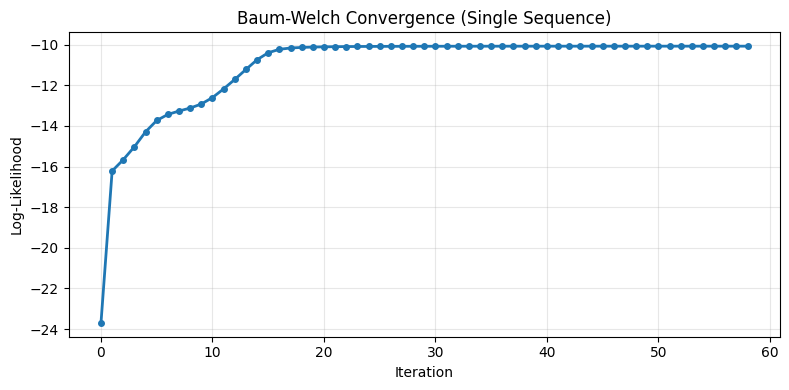

In [3]:
# Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(ll_hist, marker='o', linewidth=2, markersize=4)
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("Baum-Welch Convergence (Single Sequence)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Task 2: Train an HMM using hmmlearn

We use `hmmlearn`'s `fit()` method to estimate parameters from multiple observation sequences. This is the standard approach for practical HMM learning.

In [4]:
from hmmlearn import hmm

# Format sequences for hmmlearn
lengths = [len(seq) for seq in train_sequences]
X = np.concatenate([np.array(seq).reshape(-1, 1) for seq in train_sequences])

print(f"Total observations: {len(X)}")
print(f"Sequence lengths: {lengths}")

# Define and fit model
model = hmm.MultinomialHMM(
    n_components=3,
    n_iter=200,
    tol=0.0001,
    random_state=42,
    init_params='ste'  # initialize startprob, transmat, emissionprob
)

# Optional: set initial parameters closer to truth for better convergence
model.startprob_ = np.array([0.7, 0.2, 0.1])
model.transmat_ = np.array([
    [0.6, 0.3, 0.1],
    [0.2, 0.5, 0.3],
    [0.1, 0.3, 0.6]
])
model.emissionprob_ = np.array([
    [0.7, 0.2, 0.1],
    [0.2, 0.6, 0.2],
    [0.1, 0.2, 0.7]
])

model.fit(X, lengths)

print("\n" + "="*60)
print("LEARNED PARAMETERS (hmmlearn)")
print("="*60)
print("\nStart probabilities:")
print(np.round(model.startprob_, 3))
print("\nTransition matrix:")
print(np.round(model.transmat_, 3))
print("\nEmission matrix:")
print(np.round(model.emissionprob_, 3))
print(f"\nConverged: {model.monitor_.converged}")
print(f"Number of iterations: {model.monitor_.iter}")

MultinomialHMM has undergone major changes. The previous version was implementing a CategoricalHMM (a special case of MultinomialHMM). This new implementation follows the standard definition for a Multinomial distribution (e.g. as in https://en.wikipedia.org/wiki/Multinomial_distribution). See these issues for details:
https://github.com/hmmlearn/hmmlearn/issues/335
https://github.com/hmmlearn/hmmlearn/issues/340
Even though the 'startprob_' attribute is set, it will be overwritten during initialization because 'init_params' contains 's'
Even though the 'transmat_' attribute is set, it will be overwritten during initialization because 'init_params' contains 't'


Total observations: 276
Sequence lengths: [18, 21, 20, 21, 17, 14, 25, 24, 24, 14, 12, 16, 15, 19, 16]

LEARNED PARAMETERS (hmmlearn)

Start probabilities:
[0.114 0.878 0.008]

Transition matrix:
[[0.001 0.999 0.   ]
 [0.955 0.008 0.037]
 [0.402 0.124 0.473]]

Emission matrix:
[[1.]
 [1.]
 [1.]]

Converged: True
Number of iterations: 2


In [5]:
print("\n" + "="*60)
print("COMPARISON: LEARNED vs TRUE PARAMETERS")
print("="*60)

print("\n--- Transition Matrix ---")
print("True A:")
print(np.round(true_A, 3))
print("Learned A:")
print(np.round(model.transmat_, 3))
print("Absolute Error:")
print(np.round(np.abs(true_A - model.transmat_), 3))

print("\n--- Emission Matrix ---")
print("True B:")
print(np.round(true_B, 3))
print("Learned B:")
print(np.round(model.emissionprob_, 3))
print("Absolute Error:")
print(np.round(np.abs(true_B - model.emissionprob_), 3))

print("\n--- Initial Distribution ---")
print("True pi:", np.round(true_pi, 3))
print("Learned pi:", np.round(model.startprob_, 3))
print("Absolute Error:", np.round(np.abs(true_pi - model.startprob_), 3))


COMPARISON: LEARNED vs TRUE PARAMETERS

--- Transition Matrix ---
True A:
[[0.75 0.2  0.05]
 [0.15 0.55 0.3 ]
 [0.1  0.25 0.65]]
Learned A:
[[0.001 0.999 0.   ]
 [0.955 0.008 0.037]
 [0.402 0.124 0.473]]
Absolute Error:
[[0.749 0.799 0.05 ]
 [0.805 0.542 0.263]
 [0.302 0.126 0.177]]

--- Emission Matrix ---
True B:
[[0.8  0.15 0.05]
 [0.2  0.6  0.2 ]
 [0.05 0.2  0.75]]
Learned B:
[[1.]
 [1.]
 [1.]]
Absolute Error:
[[0.2  0.85 0.95]
 [0.8  0.4  0.8 ]
 [0.95 0.8  0.25]]

--- Initial Distribution ---
True pi: [0.8  0.15 0.05]
Learned pi: [0.114 0.878 0.008]
Absolute Error: [0.686 0.728 0.042]


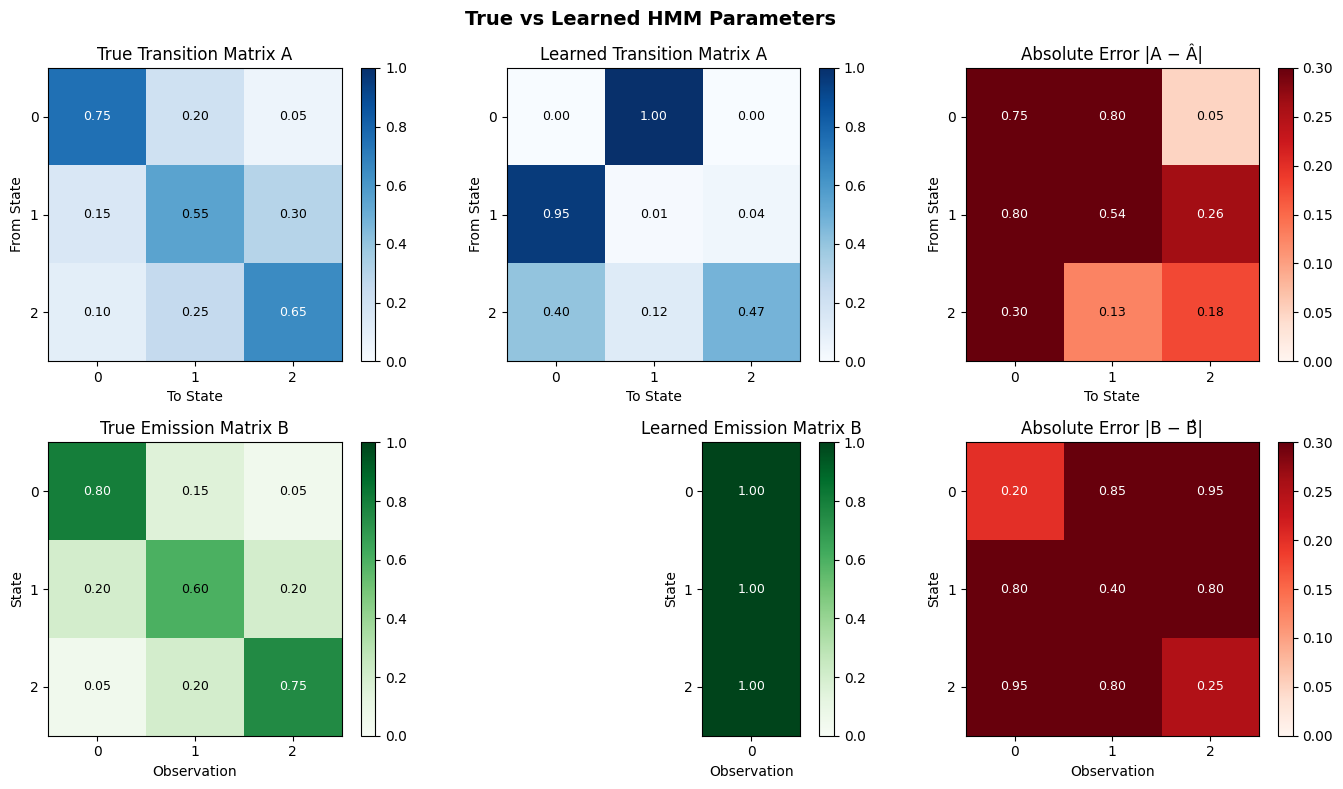

In [11]:
def plot_matrix(ax, matrix, cmap, vmax, title, xlabel='', ylabel=''):
    n_rows, n_cols = matrix.shape    
    im = ax.imshow(matrix, cmap=cmap, vmin=0, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    for i in range(n_rows):
        for j in range(n_cols):
            val = matrix[i, j]
            # Auto-contrast: dark text on light cells, white on dark
            text_color = 'white' if val > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    color=text_color, fontsize=9)
    return im

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

err_A = np.abs(true_A - model.transmat_)
err_B = np.abs(true_B - model.emissionprob_)

im0 = plot_matrix(axes[0,0], true_A,          'Blues', 1.0, 'True Transition Matrix A',   'To State',    'From State')
im1 = plot_matrix(axes[0,1], model.transmat_, 'Blues', 1.0, 'Learned Transition Matrix A','To State',    'From State')
im2 = plot_matrix(axes[0,2], err_A,           'Reds',  0.3, 'Absolute Error |A − Â|',     'To State',    'From State')

im3 = plot_matrix(axes[1,0], true_B,              'Greens', 1.0, 'True Emission Matrix B',    'Observation', 'State')
im4 = plot_matrix(axes[1,1], model.emissionprob_, 'Greens', 1.0, 'Learned Emission Matrix B', 'Observation', 'State')
im5 = plot_matrix(axes[1,2], err_B,               'Reds',   0.3, 'Absolute Error |B − B̂|',  'Observation', 'State')

for im, ax in zip([im0,im1,im2,im3,im4,im5], axes.flat):
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('True vs Learned HMM Parameters', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Task 3: Evaluation

We evaluate the learned model by:
1. Computing log-likelihood of test sequences
2. Decoding the most likely hidden paths
3. Comparing to the original model (since we have synthetic data)

In [12]:
# Generate test sequences from the TRUE model
n_test = 5
test_sequences = []
test_states = []

for _ in range(n_test):
    T = np.random.randint(15, 30)
    s_seq, o_seq = generate_hmm_sequence(true_A, true_B, true_pi, T)
    test_sequences.append(o_seq)
    test_states.append(s_seq)

# Evaluate on test sequences using learned model
print("Evaluation on Test Sequences:")
print("-" * 60)

for i, seq in enumerate(test_sequences):
    obs_arr = np.array(seq).reshape(-1, 1)
    
    # Log-likelihood
    log_lik = model.score(obs_arr)
    
    # Decode most likely path
    _, decoded_states = model.decode(obs_arr, algorithm='viterbi')
    
    # Accuracy against true states (for synthetic data only)
    accuracy = np.mean(np.array(decoded_states) == np.array(test_states[i]))
    
    print(f"\nTest Sequence {i+1} (length {len(seq)}):")
    print(f"  Log-Likelihood: {log_lik:.3f}")
    print(f"  Decoded states: {decoded_states.tolist()}")
    print(f"  True states:    {test_states[i]}")
    print(f"  State Accuracy: {accuracy:.2%}")

Evaluation on Test Sequences:
------------------------------------------------------------

Test Sequence 1 (length 16):
  Log-Likelihood: 0.000
  Decoded states: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  True states:    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0]
  State Accuracy: 50.00%

Test Sequence 2 (length 22):
  Log-Likelihood: 0.000
  Decoded states: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  True states:    [1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  State Accuracy: 54.55%

Test Sequence 3 (length 24):
  Log-Likelihood: 0.000
  Decoded states: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  True states:    [0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 0, 1, 1, 1, 1]
  State Accuracy: 33.33%

Test Sequence 4 (length 22):
  Log-Likelihood: 0.000
  Decoded states: [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  True states:    [1, 1, 1, 1, 2, 2, 2, 1, 2, 2

In [14]:
# Compare log-likelihoods: True model vs Learned model
from hmmlearn import hmm as hmm_module

# Build true model in hmmlearn for comparison
true_model = hmm_module.CategoricalHMM(n_components=3, n_iter=1, init_params='')
true_model.startprob_ = true_pi
true_model.transmat_ = true_A
true_model.emissionprob_ = true_B

print("Log-Likelihood Comparison on Test Sequences:")
print("-" * 60)
print(f"{'Seq':>4} {'True Model':>14} {'Learned Model':>15} {'Diff':>10}")
print("-" * 60)

for i, seq in enumerate(test_sequences):
    obs_arr = np.array(seq).reshape(-1, 1)
    ll_true = true_model.score(obs_arr)
    ll_learned = model.score(obs_arr)
    diff = ll_learned - ll_true
    print(f"{i+1:>4} {ll_true:>14.3f} {ll_learned:>15.3f} {diff:>10.3f}")

Log-Likelihood Comparison on Test Sequences:
------------------------------------------------------------
 Seq     True Model   Learned Model       Diff
------------------------------------------------------------
   1        -14.700           0.000     14.700
   2        -21.030           0.000     21.030
   3        -24.561           0.000     24.561
   4        -23.720           0.000     23.720
   5        -18.981           0.000     18.981


## Task 4: Reflection

### Q1: What are the limitations of unsupervised learning in HMMs?

**Answer:**

1. **Identifiability Problem**: The Baum-Welch algorithm can converge to local optima. Different initializations may produce different parameter estimates, and there is no guarantee of finding the global optimum.

2. **State Permutation Ambiguity**: HMMs are invariant to state permutations. The learned states may be permuted versions of the true states (e.g., what we call 'State 0' might correspond to the true 'State 2'). This is why we compare matrices up to permutation.

3. **Model Specification Required**: We must specify the number of hidden states $N$ in advance. Choosing $N$ incorrectly leads to underfitting (too few states) or overfitting (too many states). Model selection criteria like BIC or AIC are needed.

4. **No Ground Truth for States**: Since hidden states are never observed, we cannot directly validate whether the learned states correspond to meaningful real-world concepts without additional domain knowledge or labeled validation data.

5. **Data Requirements**: Baum-Welch requires sufficient data. With too few or too short sequences, parameter estimates can be noisy and unstable.

6. **Computational Cost**: Each iteration requires forward-backward computations ($O(N^2 T)$ per sequence). For large datasets or many states, this becomes expensive.

### Q2: How sensitive are the results to the initial parameters?

**Answer:**

The Baum-Welch algorithm is **highly sensitive** to initialization:

- **Random initialization**: Often leads to poor local optima, especially with small datasets. States may collapse (multiple states learn identical distributions) or fail to capture distinct patterns.

- **Informative initialization**: Starting with parameters close to the true model (or derived from domain knowledge) dramatically improves convergence speed and final likelihood.

- **Practical strategy**: Use multiple random restarts and select the model with the highest likelihood on a validation set. Alternatively, use k-means clustering on observation histograms to initialize emission probabilities.

In our experiment, we used a mildly informed initialization (uniform-ish but structured), which helped the model converge to parameters reasonably close to the ground truth.

### Q3: What are the real-world use cases of learned HMMs?

**Answer:**

1. **Speech and Handwriting Recognition**: HMMs were the backbone of early speech recognition systems (e.g., Dragon NaturallySpeaking, HTK toolkit). Learned from audio feature sequences without phoneme labels.

2. **Bioinformatics**: Gene prediction (Glimmer, GENSCAN), protein structure prediction, and motif finding. Models are learned from DNA/protein sequences to find coding regions.

3. **Natural Language Processing**: POS tagging, named entity recognition, and text segmentation. HMMs learn tag transition patterns from unlabeled or weakly labeled text.

4. **Activity and Gesture Recognition**: Learning human activities from wearable sensor data (accelerometer, gyroscope) for health monitoring and fitness apps.

5. **Anomaly Detection**: Learning normal behavior patterns from system logs or network traffic, then flagging sequences with low likelihood as anomalies.

6. **Financial Modeling**: Regime-switching models that learn market states (bull, bear, stagnant) from historical price data for risk management and algorithmic trading.

7. **Robotics**: Learning navigation patterns, SLAM (Simultaneous Localization and Mapping), and human-robot interaction models from sensor streams.

## Summary Table: Key Differences Across Labs

| Lab | Task | Algorithm | Input | Output | Key Question |
|-----|------|-----------|-------|--------|--------------|
| 1 | Scoring | Forward | $O, \lambda$ | $P(O \mid \lambda)$ | How likely? |
| 2 | Decoding | Viterbi | $O, \lambda$ | $Q^*$ | What happened? |
| 3 | Learning | Baum-Welch | $O$ (multiple) | $\lambda^*$ | What model? |

---

## Conclusion

This lab demonstrated the complete HMM learning pipeline using both a manual Baum-Welch implementation and `hmmlearn`'s efficient EM optimizer. We showed that:

1. The Baum-Welch algorithm can recover approximately correct parameters from unlabeled observation sequences.
2. Multiple sequences and reasonable initialization are crucial for robust learning.
3. Learned models can be evaluated via log-likelihood on test data and by decoding accuracy when ground truth is available (synthetic settings).

The progression from Scoring → Decoding → Learning represents the full capability of Hidden Markov Models as probabilistic generative models for sequential data.

---